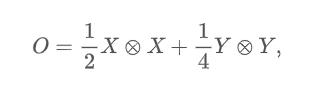

In [2]:
import pennylane as qp
import numpy as np

In [ ]:
# If we want to define the Hermitian Operator above, we write...

O = 1/2 * qp.X(0) @ qp.X(1) + 1/4 * qp.Y(0) @ qp.Y(1)

# Here, the symbol @ denotes the tensor product between PennyLane operators, 
# and the arguments 0 and 1 are the wires on which the operators X and Y act.

In [15]:
# Samples
dev = qp.device("default.qubit", wires = 1, shots = 10)

@qp.qnode(dev)
def circuit():
    qp.Hadamard(wires = 0)
    return qp.sample()
print(circuit())

[[0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]]


In [16]:
@qp.qnode(dev)
def circuit_paulix():
    qp.Hadamard(wires = 0)
    return qp.sample(qp.X(0))
print(circuit_paulix())

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [20]:
# Counts
dev = qp.device("default.qubit", wires=1, shots=1000)

@qp.qnode(dev)
def circuit_counts():
    qp.Hadamard(wires=0)
    return qp.counts()
print(circuit_counts())

{np.str_('0'): np.int64(479), np.str_('1'): np.int64(521)}


In [21]:
@qp.qnode(dev)
def circuit_paulix():
    qp.Hadamard(wires = 0)
    return qp.counts(qp.X(0))
print(circuit_paulix())

{np.float64(1.0): np.int64(1000)}


In [25]:
# Probabilities
dev = qp.device("default.qubit", wires=2)

@qp.qnode(dev)
def simple_circuit():
    qp.X(wires=1)
    return qp.probs()
print(simple_circuit())

[0. 1. 0. 0.]


In [27]:
@qp.qnode(dev)
def simple_circuit():
    qp.X(wires=1)
    return qp.probs(wires=0)
print(simple_circuit())

[1. 0.]


In [28]:
dev = qp.device("default.qubit", wires=2)

@qp.qnode(dev)
def prob_circuit_paulix():
    qp.X(wires=1)
    return qp.probs(op = qp.X(0) @ qp.X(1))
print(prob_circuit_paulix())

[0.25 0.25 0.25 0.25]


In [32]:
# Expectation values
dev = qp.device("default.qubit", wires=2)

@qp.qnode(dev)
def simple_circuit_expval():
    qp.X(wires=1)
    return qp.expval(qp.PauliZ(0))
print(simple_circuit_expval())

1.0


In [33]:
dev = qp.device("default.qubit", wires=2)

@qp.qnode(dev)
def expval_circuit():
    qp.RY(np.pi/4, wires=0)
    qp.RX(np.pi/3, wires=1)
    qp.CNOT(wires=[0, 1])
    return qp.expval(1/3*qp.PauliZ(0) @ qp.PauliZ(1))
print(expval_circuit())

0.16666666666666669


In [ ]:
# Codercise PF.3.1 - Taking samples
dev = qp.device("default.qubit", wires=2, shots=1)

@qp.qnode(dev)
def circuit():
    """
    This quantum function implements the circuit shown above
    and should return a sample from all qubits
    """

    qp.H(wires=0)
    qp.CNOT(wires=[0,1])

    return qp.sample()

print(circuit())

[[1 1]]


In [58]:
# Codercise PF.3.2 - Hermitian observable
dev = qp.device("default.qubit", wires=2)

A = np.array([[1, 0], [0, -1]])

@qp.qnode(dev)
def circuit():
    """
    This quantum function implements the circuit shown above
    and should return a sample from all qubits
    """

    qp.H(wires=0)
    qp.CNOT(wires=[0,1])
    return qp.expval(op = qp.Hermitian(A, wires=0))

print(circuit())

0.0


In [62]:
# Codercise - Tensor observablesç
dev = qp.device("default.qubit", wires=2)

@qp.qnode(dev)
def circuit():
    """
    This quantum function implements a Bell state and
    should return the probabilities for the PauliZ 
    observable on both qubits, using a single measurement
    """
    qp.H(wires=0)
    qp.CNOT(wires=[0,1])
    return qp.probs(qp.Z(wires=0) @ qp.Z(wires=1))